Imports:

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.metrics import f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from scipy.sparse import hstack

LOAD DATA

In [2]:
df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

print("Shape:", df.shape)
df.head()
print(df.isnull().sum())


Shape: (198000, 15)
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


Target Distribution

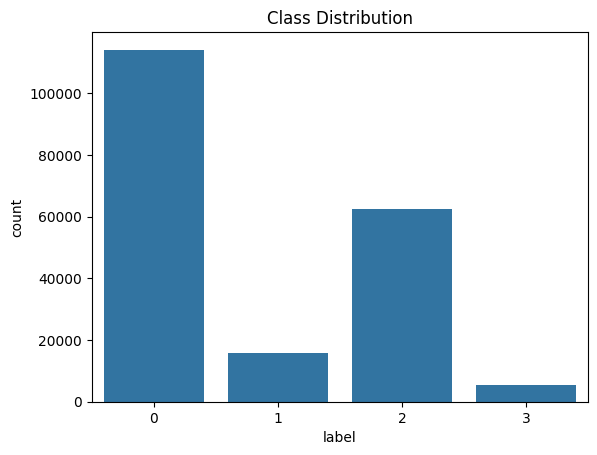

In [3]:
sns.countplot(x="label", data=df)
plt.title("Class Distribution")
plt.show()

Comment Length

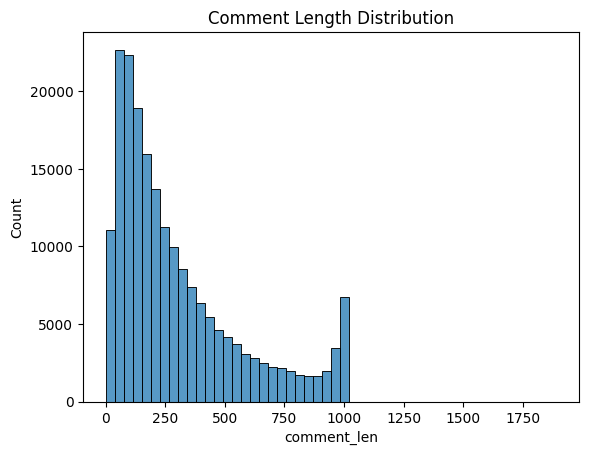

In [4]:
df["comment"] = df["comment"].fillna("")
df["comment_len"] = df["comment"].apply(len)

sns.histplot(df["comment_len"], bins=50)
plt.title("Comment Length Distribution")
plt.show()

Correlation Heatmap

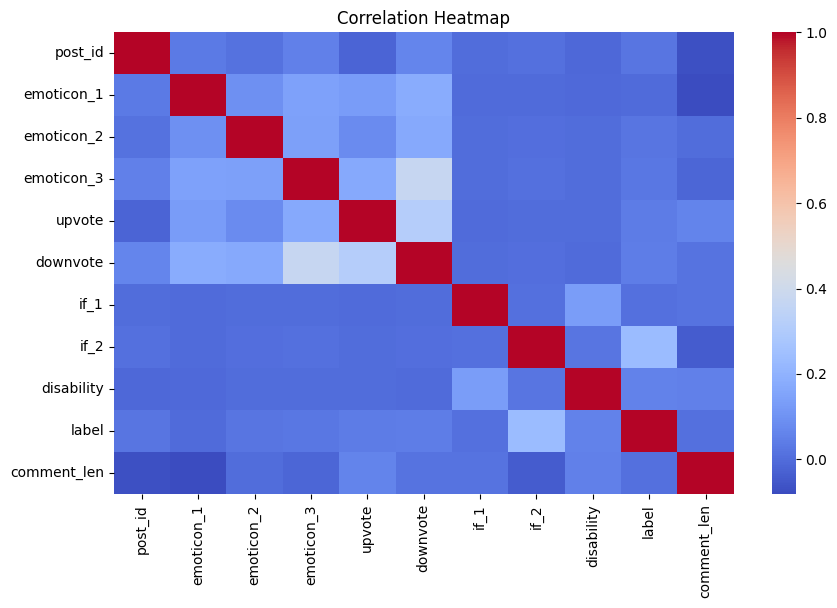

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

CLEAN DATA AND TRAIN-VALIDATION SPLIT

In [6]:
df["comment"] = df["comment"].fillna("")
test_df["comment"] = test_df["comment"].fillna("")
y = df["label"]
X = df.drop("label", axis=1)

x_train, x_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2306,
    stratify=y
)

FEATURE ENGINEERING

In [7]:
def process_date(data):
    data["created_date"] = pd.to_datetime(data["created_date"])
    data["year"] = data["created_date"].dt.year
    data["month"] = data["created_date"].dt.month
    data["hour"] = data["created_date"].dt.hour
    return data.drop("created_date", axis=1)

def add_text_features(df):
    df["comment"] = df["comment"].fillna("").astype(str)

    df["char_count"] = df["comment"].apply(len)
    df["word_count"] = df["comment"].apply(lambda x: len(x.split()))
    df["avg_word_len"] = df["char_count"] / (df["word_count"] + 1)

    df["num_exclaim"] = df["comment"].str.count(r"\!")
    df["num_question"] = df["comment"].str.count(r"\?")
    df["num_caps"] = df["comment"].str.count(r"[A-Z]")
    df["num_digits"] = df["comment"].str.count(r"\d")

    return df

x_train = process_date(x_train)
x_val = process_date(x_val)
test_df = process_date(test_df)

x_train = add_text_features(x_train)
x_val = add_text_features(x_val)
test_df = add_text_features(test_df)
text_train = x_train.pop("comment")
text_val = x_val.pop("comment")
text_test = test_df.pop("comment")

TABULAR PREPROCESSING

In [8]:
# Categorical columns
cat_cols = ["race", "religion", "gender", "disability"]

# Numerical columns (explicit + engineered)
num_cols = [
    "post_id", "emoticon_1", "emoticon_2", "emoticon_3",
    "upvote", "downvote", "if_1", "if_2",
    "year", "month", "hour",
    "char_count", "word_count", "avg_word_len",
    "num_exclaim", "num_question"
]
for col in num_cols:
    x_train[col] = pd.to_numeric(x_train[col], errors="coerce")
    x_val[col] = pd.to_numeric(x_val[col], errors="coerce")
    test_df[col] = pd.to_numeric(test_df[col], errors="coerce")
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer([

    ("cat",
     Pipeline([
         ("imputer", SimpleImputer(strategy="most_frequent")),
         ("encoder", OneHotEncoder(handle_unknown="ignore"))
     ]),
     cat_cols),

    ("num",
     Pipeline([
         ("imputer", SimpleImputer(strategy="mean")),
         ("scaler", StandardScaler())
     ]),
     num_cols)
],
remainder="drop"   # drop anything unexpected
)
X_train_tab = preprocessor.fit_transform(x_train)
X_val_tab = preprocessor.transform(x_val)
X_test_tab = preprocessor.transform(test_df)

TEXT PROCESSING

In [9]:
def clean_text(text):
    return re.sub(r"http\S+|www\S+|\s+", " ", text).strip()

text_train = text_train.apply(clean_text)
text_val = text_val.apply(clean_text)
text_test = text_test.apply(clean_text)

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=25000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

tf_train = tfidf.fit_transform(text_train)
tf_val = tfidf.transform(text_val)
tf_test = tfidf.transform(text_test)

COMBINE FEATURES AND DIMENSION REDUCTION

In [10]:
X_train = hstack([X_train_tab, tf_train])
X_val = hstack([X_val_tab, tf_val])
X_test = hstack([X_test_tab, tf_test])


TRAIN MULTIPLE MODELS

In [11]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import SGDClassifier
from lightgbm import LGBMClassifier

class_weights = {0:1, 1:2, 2:1, 3:8}

lr = LogisticRegression(
    max_iter=2000,
    solver="saga",
    class_weight=class_weights,
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=6,
    n_jobs=-1,
    random_state=2306
)

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=80,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight={0:1, 1:2, 2:1, 3:10},
    random_state=2306,
    n_jobs=-1
)

sgd = SGDClassifier(
    loss="log_loss",        
    alpha=1e-5,              
    penalty="l2",
    max_iter=2000,
    class_weight={0:1, 1:2, 2:1, 3:8},   
    random_state=2306,
    n_jobs=-1
)
voting = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("lgbm", lgbm)
    ],
    voting="soft",
    weights=[2, 4]   
)
models = {
    "Logistic Regression": lr,
    "XGBoost": xgb,
    "LIGHTGBM": lgbm,
    "Voting Classifier": voting
}

TRAIN + COMPARE (MACRO F1)

In [12]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    
    score = f1_score(y_val, pred, average="macro")
    results[name] = score
    
    print(f"{name} Macro F1: {round(score,4)}")


Training Logistic Regression...
Logistic Regression Macro F1: 0.7997

Training XGBoost...
XGBoost Macro F1: 0.7769

Training LIGHTGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 28.745834 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 907322
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 23592
[LightGBM] [Info] Start training from score -0.834966
[LightGBM] [Info] Start training from score -2.112032
[LightGBM] [Info] Start training from score -1.438471
[LightGBM] [Info] Start training from score -1.571042
LIGHTGBM Macro F1: 0.8151

Training Voting Classifier...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 26.991594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 907322
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 235

MODEL COMPARISON

In [13]:
print("\nMODEL COMPARISON")

for name, score in results.items():
    print(f"{name}: {round(score,4)}")
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)


MODEL COMPARISON
Logistic Regression: 0.7997
XGBoost: 0.7769
LIGHTGBM: 0.8151
Voting Classifier: 0.8203

Best Model: Voting Classifier


CONFUSION MATRIX

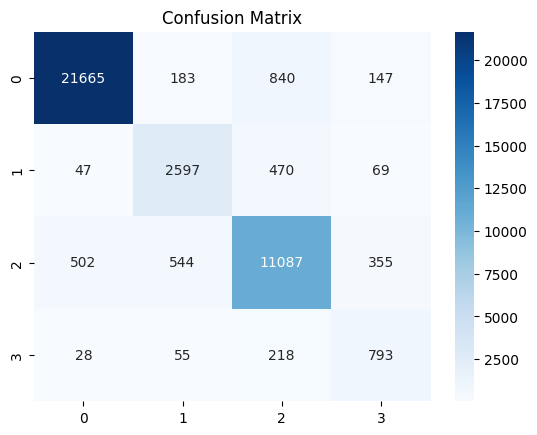

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     22835
           1       0.77      0.82      0.79      3183
           2       0.88      0.89      0.88     12488
           3       0.58      0.72      0.65      1094

    accuracy                           0.91     39600
   macro avg       0.80      0.84      0.82     39600
weighted avg       0.92      0.91      0.91     39600



In [14]:
pred = best_model.predict(X_val)

cm = confusion_matrix(y_val, pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_val, pred))

FINAL SUBMISSION

In [15]:
best_model.fit(X_train, y_train)

test_pred = best_model.predict(X_test)

sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

submission = sample.copy()
submission.iloc[:, 1] = test_pred

submission.to_csv("submission.csv", index=False)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 33.539038 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 907322
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 23592
[LightGBM] [Info] Start training from score -0.834966
[LightGBM] [Info] Start training from score -2.112032
[LightGBM] [Info] Start training from score -1.438471
[LightGBM] [Info] Start training from score -1.571042
